In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/gait.csv')

df

,cycle,subject,measure,value
0,0.025,boy1,Hip Angle,37.0
1,0.025,boy1,Knee Angle,10.0
2,0.025,boy2,Hip Angle,47.0
3,0.025,boy2,Knee Angle,16.0
4,0.025,boy3,Hip Angle,46.0
...,...,...,...,...
1555,0.975,boy37,Knee Angle,7.0
1556,0.975,boy38,Hip Angle,59.0
1557,0.975,boy38,Knee Angle,20.0
1558,0.975,boy39,Hip Angle,55.0


Text(0, 0.5, 'Hip Angle (degrees)')

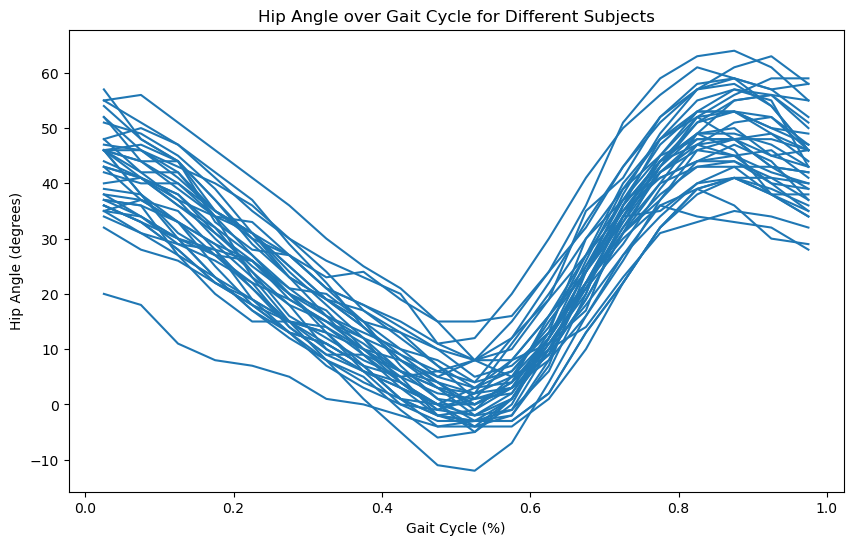

In [2]:
df_h = df[df['measure'] == 'Hip Angle']
df_k = df[df['measure'] == 'Knee Angle']

df_h = df_h[['cycle','subject','value']].pivot(columns='subject', index='cycle')
time = df_h.index.values
values_h = df_h.values

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
for i in range(values_h.shape[1]):
    ax.plot(time, values_h[:,i], alpha=1.0, color='C0')
ax.set_title('Hip Angle over Gait Cycle for Different Subjects')
ax.set_xlabel('Gait Cycle (%)')
ax.set_ylabel('Hip Angle (degrees)')


Text(0, 0.5, 'Knee Angle (degrees)')

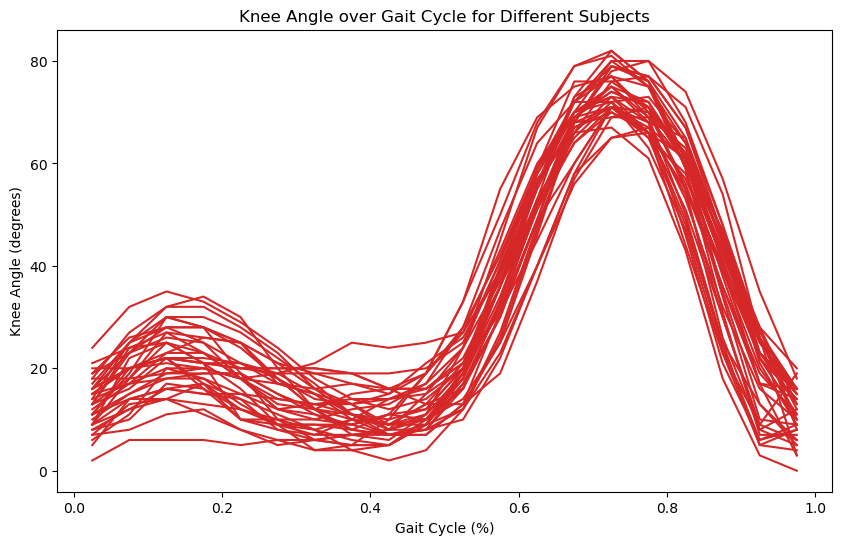

In [3]:
df_k = df_k[['cycle','subject','value']].pivot(columns='subject', index='cycle')
values_k = df_k.values

fig, ax = plt.subplots(figsize=(10,6))
for i in range(values_k.shape[1]):
    ax.plot(time, values_k[:,i], alpha=1.0, color='C3')
ax.set_title('Knee Angle over Gait Cycle for Different Subjects')
ax.set_xlabel('Gait Cycle (%)')
ax.set_ylabel('Knee Angle (degrees)')

In [4]:
values_k.shape, values_h.shape, time.shape

((20, 39), (20, 39), (20,))

In [5]:
import MultivariateBLF.MultivariateBLF as mvt

fdata_k = \
mvt.FunctionalData(
    coords=time,
    data=values_k
)

fdata_k.set_GP_basis(n_basis=20, gaussian_process='matern5/2', gp_lengthscale=0.1, gp_variance=np.square(20))


fdata_h = \
mvt.FunctionalData(
    coords=time,
    data=values_h
)

fdata_h.set_GP_basis(n_basis=20, gaussian_process='matern5/2', gp_lengthscale=0.1, gp_variance=np.square(30))



In [6]:
model = mvt.MvtBLF( # first will be knee second will be hip
    n_components = 3,
    D =  2,
    heteroscedastic_thetas = True,
    MGPS = True,
    local_shrinkage_LatentFactors = True,
    absence_of_psi2 = [False, False],
    # sampling / build config
    n_chains = 16,
    iter_warmup = 3000,
    iter_sampling = 500,
    thin = 1,
    max_treedepth = 12,
    stan_seed = 12345,
    # ---- explicit prior hyperparameters (scalars or length-D vectors) ----
    a_psi = [5.0, 5.0],
    b_psi = [0.1, 0.1],
    a_tau = [2.0, 2.0],
    b_tau = [2.0, 2.0],
    # MGPS (used if MGPS=True)
    a1 = 2.0,
    a2 = 2.1,
    # rate parameter is used in both cases, the classical MGPS has b = 1.0
    b_lambdavar = 1.0,
    # Student-t df for Lambda (used if local_shrinkage_LatentFactors=True)
    nu = 7.0,
)

In [7]:
model.fit(
    X=np.ones((1,39)),
    modes=[fdata_k, fdata_h]
)

09:56:00 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 14 |          | 00:00 Status

chain 15 |          | 00:00 Status

chain 16 |          | 00:00 Status

10:06:29 - cmdstanpy - INFO - CmdStan done processing.
10:06:29 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable[8] is 0, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', line 109, column 2 to column 35)
	Exception: gamma_lpdf: Random variable[8] is 0, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', line 109, column 2 to column 35)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', line 86, column 2 to column 26)
	Exception: gamma_lpdf: Random variable[5] is 0, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', line 92, column 2 to column 35)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', line 86, column 2 to column 26)
	Exception: gamma_lpdf: Random variable[2] is 0, but must be positive finite! (in 'MBLF_D2_MGPS1_t1_het11_psi211.stan', l

10:06:29 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 4 had 1 iterations at max treedepth (0.2%)
	Chain 11 had 8 iterations at max treedepth (1.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [8]:
model.save('res')

In [9]:
model2 = mvt.MvtBLF.load('res')

In [10]:
model2.idata.posterior

<xarray.Dataset> Size: 118MB
Dimensions:                   (chain: 16, draw: 500, regr_coeffs_dim_0: 3,
                               regr_coeffs_dim_1: 1, eta_dim_0: 3,
                               eta_dim_1: 39, Lambda1_dim_0: 20,
                               Lambda1_dim_1: 3, tau1_dim_0: 20,
                               theta1_dim_0: 20, theta1_dim_1: 39,
                               Lambda2_dim_0: 20, Lambda2_dim_1: 3,
                               tau2_dim_0: 20, theta2_dim_0: 20,
                               theta2_dim_1: 39, delta_dim_0: 3,
                               unconstrained_psi2_dim_0: 2, psi2_dim_0: 2,
                               omega_dim_0: 3)
Coordinates: (12/20)
  * chain                     (chain) int64 128B 0 1 2 3 4 5 ... 11 12 13 14 15
  * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
  * regr_coeffs_dim_0         (regr_coeffs_dim_0) int64 24B 0 1 2
  * regr_coeffs_dim_1         (regr_coeffs_dim_1) int64 8B 0
  * eta_dim_0                 (eta_dim_0) int64 24B 0 1 2
  * eta_dim_1                 (eta_dim_1) int64 312B 0 1 2 3 4 ... 35 36 37 38
    ...                        ...
  * theta2_dim_0              (theta2_dim_0) int64 160B 0 1 2 3 ... 16 17 18 19
  * theta2_dim_1              (theta2_dim_1) int64 312B 0 1 2 3 ... 35 36 37 38
  * delta_dim_0               (delta_dim_0) int64 24B 0 1 2
  * unconstrained_psi2_dim_0  (unconstrained_psi2_dim_0) int64 16B 0 1
  * psi2_dim_0                (psi2_dim_0) int64 16B 0 1
  * omega_dim_0               (omega_dim_0) int64 24B 0 1 2
Data variables:
    regr_coeffs               (chain, draw, regr_coeffs_dim_0, regr_coeffs_dim_1) float64 192kB ...
    eta                       (chain, draw, eta_dim_0, eta_dim_1) float64 7MB ...
    Lambda1                   (chain, draw, Lambda1_dim_0, Lambda1_dim_1) float64 4MB ...
    tau1                      (chain, draw, tau1_dim_0) float64 1MB ...
    theta1                    (chain, draw, theta1_dim_0, theta1_dim_1) float64 50MB ...
    Lambda2                   (chain, draw, Lambda2_dim_0, Lambda2_dim_1) float64 4MB ...
    tau2                      (chain, draw, tau2_dim_0) float64 1MB ...
    theta2                    (chain, draw, theta2_dim_0, theta2_dim_1) float64 50MB ...
    delta                     (chain, draw, delta_dim_0) float64 192kB ...
    unconstrained_psi2        (chain, draw, unconstrained_psi2_dim_0) float64 128kB ...
    psi2                      (chain, draw, psi2_dim_0) float64 128kB ...
    omega                     (chain, draw, omega_dim_0) float64 192kB ...
Attributes:
    created_at:                 2026-01-21T10:06:30.924286+00:00
    arviz_version:              0.22.0
    inference_library:          cmdstanpy
    inference_library_version:  1.2.5